
Low stock alert : 3 : Drugs are low in stock
        Drug  Stock  Reorder_Level    Status
     Aspirin     80            150 LOW_STOCK
Atorvastatin     50            100 LOW_STOCK
    Warfarin    120            200 LOW_STOCK


/var/folders/ll/jf0j17hd5vl4hsvyy49gbrxc0000gn/T/ipykernel_72031/3132444647.py:52: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ll/jf0j17hd5vl4hsvyy49gbrxc0000gn/T/ipykernel_72031/3132444647.py:52: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/ll/jf0j17hd5vl4hsvyy49gbrxc0000gn/T/ipykernel_72031/3132444647.py:53: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("stock_dashboard.png",
/var/folders/ll/jf0j17hd5vl4hsvyy49gbrxc0000gn/T/ipykernel_72031/3132444647.py:53: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("stock_dashboard.png",
/Users/shashank/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

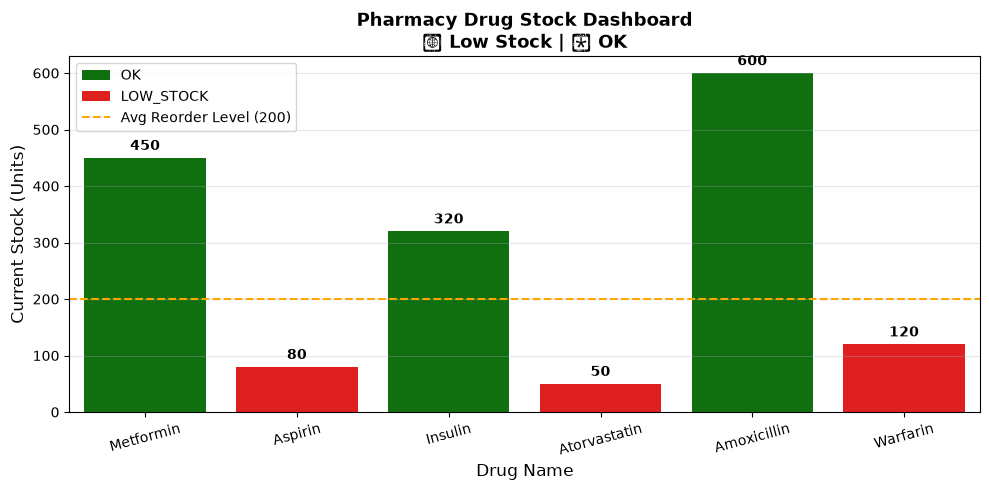


  stock_data.csv saved
  stock_dashboard.png saved


In [14]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

#1 conversion of daat into data frame

data = {
    "Drug": ['Metformin','Aspirin','Insulin','Atorvastatin','Amoxicillin','Warfarin'],
    "Stock" : [450,80,320,50,600,120],
    "Reorder_Level" : [200,150,300,100,250,200]
}

df = pd.DataFrame(data)

#2 adding status column

df['Status'] = df.apply(lambda x: "LOW_STOCK" if x['Stock'] < x['Reorder_Level'] else "OK", axis = 1)

#3 low sock alert print and save 

low = df[df['Status'] == "LOW_STOCK"]
print(f"\nLow stock alert : {len(low)} : Drugs are low in stock")
print(low[['Drug','Stock','Reorder_Level','Status']].to_string(index = False))

#4 seaborn plotting 
colors = ['red' if x == 'LOW_STOCK' else 'green' for x in df['Status']]

plt.figure(figsize = (10,5))
ax = sns.barplot(x='Drug', y='Stock', hue='Status', data=df, palette={'LOW_STOCK':'red', 'OK':'green'})

avg_reorder = df["Reorder_Level"].mean()
plt.axhline(y=avg_reorder,
            color="orange",
            linestyle="--",
            linewidth=1.5,
            label=f"Avg Reorder Level ({avg_reorder:.0f})")

for i, row in df.iterrows():
    ax.text(i, row["Stock"] + 8,
            str(row["Stock"]),
            ha="center", va="bottom",
            fontsize=10, fontweight="bold")
    
plt.title("Pharmacy Drug Stock Dashboard\n"
          "🔴 Low Stock | 🟢 OK",
          fontsize=13, fontweight="bold")
plt.xlabel("Drug Name", fontsize=12)
plt.ylabel("Current Stock (Units)", fontsize=12)
plt.xticks(rotation=15)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("stock_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()

#5 saving to csv
df.to_csv("stock_dashboard.csv", index = False)
print("\n  stock_data.csv saved")
print("  stock_dashboard.png saved")

